In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# Loading the datasets

# Fina:
mld_fina = xr.open_dataset(r'C:\Users\tilde\Documents\GitHub\Cyclone-Analysis\MLD\Fina\cmems_mod_glo_phy-all_my_0.25deg_P1D-m_1776783357250.nc')

# Alfred:
mld_alfred = xr.open_dataset(r'C:\Users\tilde\Documents\GitHub\Cyclone-Analysis\MLD\Alfred\cmems_mod_glo_phy_anfc_0.083deg_P1D-m_1776782816966.nc')

#Baseline:
mld_baseline = xr.open_mfdataset(
    r'C:\Users\tilde\Documents\GitHub\Cyclone-Analysis\MLD\Baseline\Baseline_old\*.nc',
    combine='by_coords'
)


In [3]:
# Checking variable names
print(mld_fina)

<xarray.Dataset> Size: 7kB
Dimensions:      (time: 62, latitude: 5, longitude: 5)
Coordinates:
  * time         (time) datetime64[ns] 496B 2011-12-01 2011-12-02 ... 2012-01-31
  * latitude     (latitude) float32 20B -19.5 -19.25 -19.0 -18.75 -18.5
  * longitude    (longitude) float32 20B 155.0 155.2 155.5 155.8 156.0
Data variables:
    mlotst_cglo  (time, latitude, longitude) float32 6kB ...
Attributes: (12/13)
    Conventions:       CF-1.11
    title:             Daily mean fields for product GLOBAL_MULTIYEAR_PHY_ENS...
    institution:       Mercator Ocean
    producer:          CMEMS - Global Monitoring and Forecasting Centre
    source:            Copernicus Marine Service
    history:           Creation 2023-October-31 12:35:28 GMT+0200
    ...                ...
    contact:           servicedesk.cmems@mercator-ocean.eu
    references:        http://marine.copernicus.eu
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL

In [4]:
# Extracting the MLD variable and time from each dataset
mld_fina = mld_fina['mlotst_cglo']
mld_alfred = mld_alfred['mlotst']
mld_baseline = mld_baseline['mlotst_cglo']

In [5]:
# Excluding cyclones from baseline
exclude_periods = [
    ('2020-02-04', '2020-02-14'),
    ('2020-03-14', '2020-03-15'),
    ('2021-01-16', '2021-01-19'),
    ('2021-01-24', '2021-02-01'),
    ('2021-02-27', '2021-03-05'),
    ('2021-12-09', '2021-12-15'),
    ('2022-02-07', '2022-02-12')
]

In [6]:
# Creating a mask for the baseline dataset
mask = xr.ones_like(mld_baseline.time, dtype=bool)

for start, end in exclude_periods:
    mask = mask & ~((mld_baseline.time >= np.datetime64(start)) &
                    (mld_baseline.time <= np.datetime64(end)))

# Applying the mask to the baseline dataset
mld_baseline_clean = mld_baseline.sel(time=mask)        
    

In [7]:
# Spatial means
dims = ("latitude", "longitude")

mld_ts_fina = mld_fina.mean(dim=dims)
mld_ts_alfred = mld_alfred.mean(dim=dims)
mld_ts_baseline = mld_baseline_clean.mean(dim=dims)

# Baseline mean
mld_baseline_mean = mld_ts_baseline.mean(dim='time')

In [8]:
# Anomalies
baseline_on_alfred = mld_baseline_mean.interp_like(mld_ts_alfred)
mld_alfred_anomaly = mld_ts_alfred - baseline_on_alfred

baseline_on_fina = mld_baseline_mean.interp_like(mld_ts_fina)
mld_fina_anomaly = mld_ts_fina - baseline_on_fina


print("Max MLD anomaly for Alfred:", mld_alfred_anomaly.max().values, "m")
print("Max MLD anomaly for Fina:", mld_fina_anomaly.max().values, "m")

Max MLD anomaly for Alfred: 31.539574 m
Max MLD anomaly for Fina: 11.600531 m


In [9]:
# Converting to "days since first data point" so I can plot both in one graph
mld_ts_fina_rel = mld_ts_fina.copy()
mld_ts_alfred_rel = mld_ts_alfred.copy()

mld_ts_fina_rel['time'] = (mld_ts_fina.time - mld_ts_fina.time[0]) / np.timedelta64(1, 'D')
mld_ts_alfred_rel['time'] = (mld_ts_alfred.time - mld_ts_alfred.time[0]) / np.timedelta64(1, 'D')

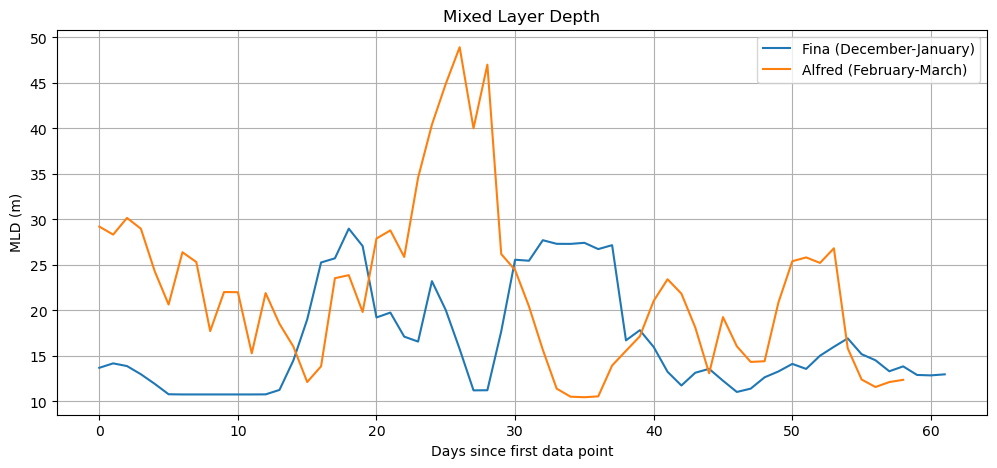

In [10]:
# Plotting time series for ALfred and Fina

fig, ax = plt.subplots(figsize=(12, 5))

mld_ts_fina_rel.plot(ax=ax, label='Fina (December-January)')
mld_ts_alfred_rel.plot(ax=ax, label='Alfred (February-March)')

ax.legend()
ax.set_title("Mixed Layer Depth")
ax.set_ylabel("MLD (m)")
ax.set_xlabel("Days since first data point")

ax.grid(True)

In [11]:
# Adding day-of-year coordinates for baseline but only for Dec-Mar
mld_ts_season = mld_ts_baseline.where(
    mld_ts_baseline['time'].dt.month.isin([11, 12, 1, 2, 3]),
    drop=True
)

mld_ts_season = mld_ts_season.assign_coords(
    dayofyear=mld_ts_season['time'].dt.dayofyear
)

In [12]:
# Grouping it by day of year and taking the mean to get climatology
mld_clim = mld_ts_season.groupby('dayofyear').mean(dim='time')

In [13]:
# Setting November as first day of the season (day 0) and March as last day (day 151)
doy = mld_clim['dayofyear']

season_index = xr.where(
    doy >= 305,              # Nov–Dec
    doy - 305,              # shift Nov 1 → 0
    doy + (365 - 305 + 1)    # Jan–Mar continues after Dec
)

mld_clim = mld_clim.assign_coords(season_index=season_index)


In [14]:
# Sorting it by the new season index
mld_clim = mld_clim.sortby('season_index')

[Text(0, 0, 'Nov'),
 Text(30, 0, 'Dec'),
 Text(61, 0, 'Jan'),
 Text(92, 0, 'Feb'),
 Text(120, 0, 'Mar')]

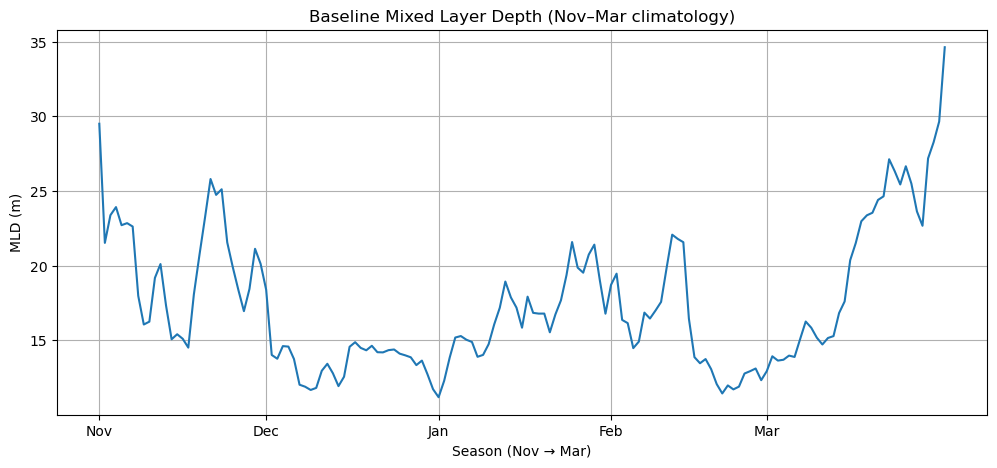

In [15]:
# Plotting baseline MLD
fig, ax = plt.subplots(figsize=(12, 5))

mld_clim.plot(ax=ax, x='season_index')

ax.set_title("Baseline Mixed Layer Depth (Nov–Mar climatology)")
ax.set_xlabel("Season (Nov → Mar)")
ax.set_ylabel("MLD (m)")
ax.grid(True)

ax.set_xticks([0, 30, 61, 92, 120])
ax.set_xticklabels(["Nov", "Dec", "Jan", "Feb", "Mar"])

In [16]:
# Convert anomaly time to "days since first data point" so I can plot it

mld_fina_anomaly_rel = mld_fina_anomaly.copy()
mld_alfred_anomaly_rel = mld_alfred_anomaly.copy()

mld_fina_anomaly_rel['time'] = (
    mld_fina_anomaly.time - mld_fina_anomaly.time[0]
) / np.timedelta64(1, 'D')

mld_alfred_anomaly_rel['time'] = (
    mld_alfred_anomaly.time - mld_alfred_anomaly.time[0]
) / np.timedelta64(1, 'D')

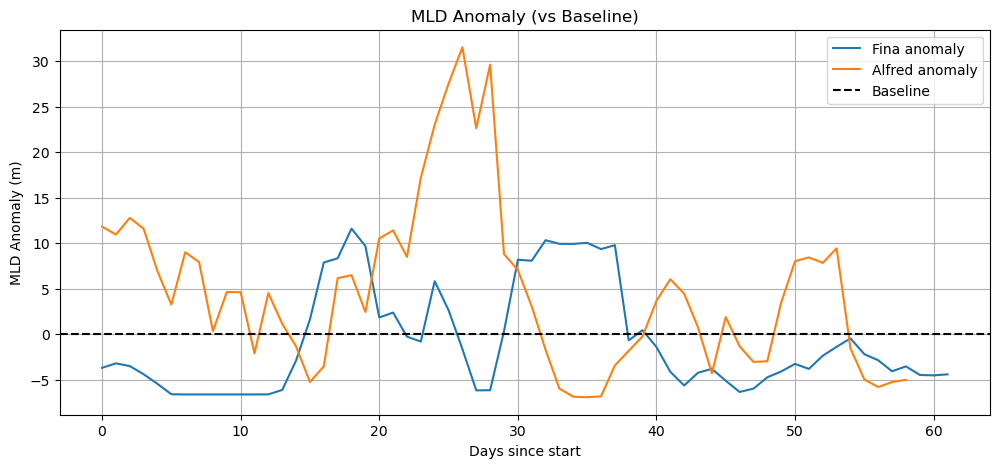

In [17]:
# Plotting anomalies versus baseline

fig, ax = plt.subplots(figsize=(12, 5))

mld_fina_anomaly_rel.plot(ax=ax, label='Fina anomaly')
mld_alfred_anomaly_rel.plot(ax=ax, label='Alfred anomaly')

ax.axhline(0, color='black', linestyle='--',label='Baseline')

ax.legend()
ax.set_title("MLD Anomaly (vs Baseline)")
ax.set_ylabel("MLD Anomaly (m)")
ax.set_xlabel("Days since start")

ax.grid(True)

In [18]:
# Spatial data for map plots
mld_alfred_3d = mld_alfred
mld_fina_3d   = mld_fina

In [19]:
# Spatial baseline mean
mld_baseline_mean = mld_baseline.mean(dim="time", skipna=True)

In [20]:
# Interpolating baseline to cyclone grid
baseline_on_alfred = mld_baseline_mean.interp_like(mld_alfred_3d)
baseline_on_fina   = mld_baseline_mean.interp_like(mld_fina_3d)

In [21]:
# Getting the anomalies spatially and not just as a timeseries
mld_alfred_anomaly = mld_alfred_3d - baseline_on_alfred
mld_fina_anomaly   = mld_fina_3d - baseline_on_fina

Text(0.5, 1.0, 'Mean deviation (anomaly) for cyclone Alfred')

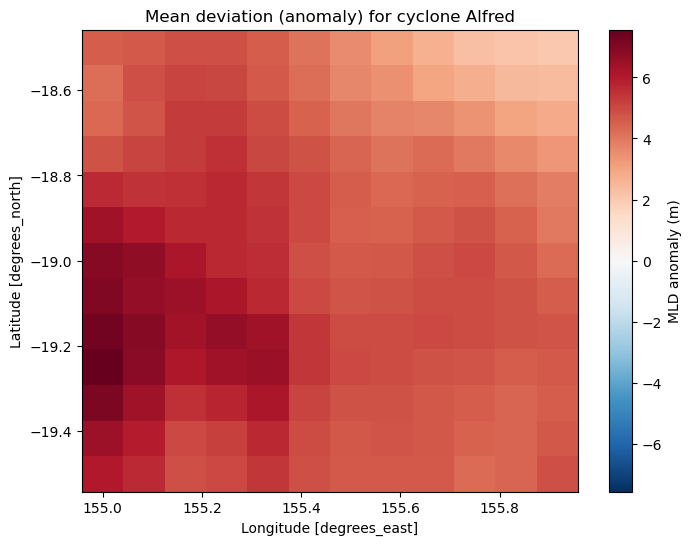

In [22]:
# Mean anomaly map for Alfred
fig, ax = plt.subplots(figsize=(8,6))

mld_alfred_anomaly.mean(dim="time", skipna=True).plot(
    ax=ax,
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "MLD anomaly (m)"}
)

ax.set_title("Mean deviation (anomaly) for cyclone Alfred")

Text(0.5, 1.0, 'Mean deviation (anomaly) for cyclone Fina')

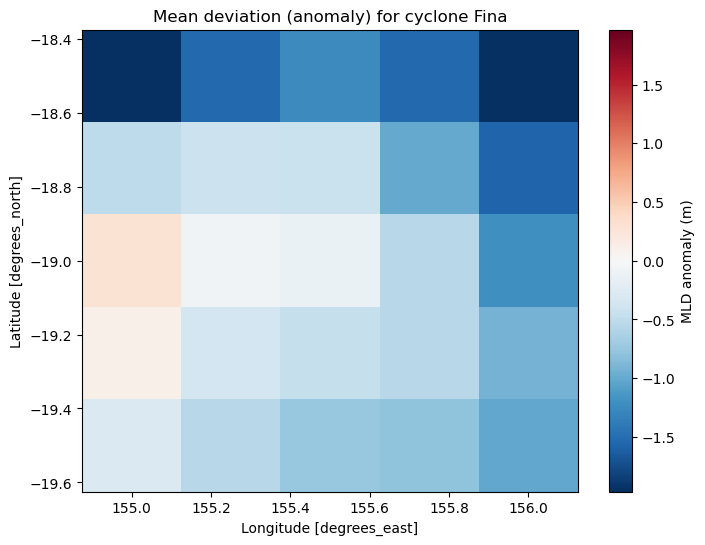

In [23]:
# Mean anomaly map for Fina
fig, ax = plt.subplots(figsize=(8,6))

mld_fina_anomaly.mean(dim="time", skipna=True).plot(
    ax=ax,
    cmap="RdBu_r",
    center=0,
    cbar_kwargs={"label": "MLD anomaly (m)"}
)

ax.set_title("Mean deviation (anomaly) for cyclone Fina")

Text(0.5, 1.0, 'Standard deviation map for cyclone Alfred')

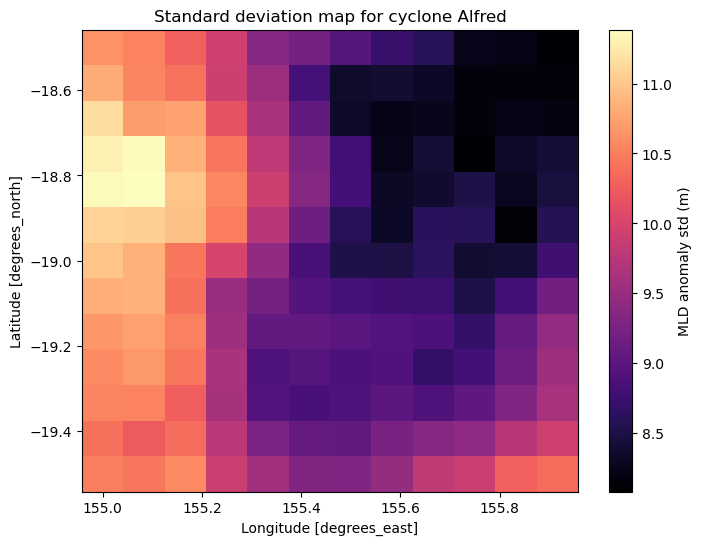

In [24]:
# Standard deviation map for Alfred
fig, ax = plt.subplots(figsize=(8,6))

mld_alfred_anomaly.std(dim="time", skipna=True).plot(
    ax=ax,
    cmap="magma",
    cbar_kwargs={"label": "MLD anomaly std (m)"}
)

ax.set_title("Standard deviation map for cyclone Alfred")

Text(0.5, 1.0, 'Standard deviation map for cyclone Fina')

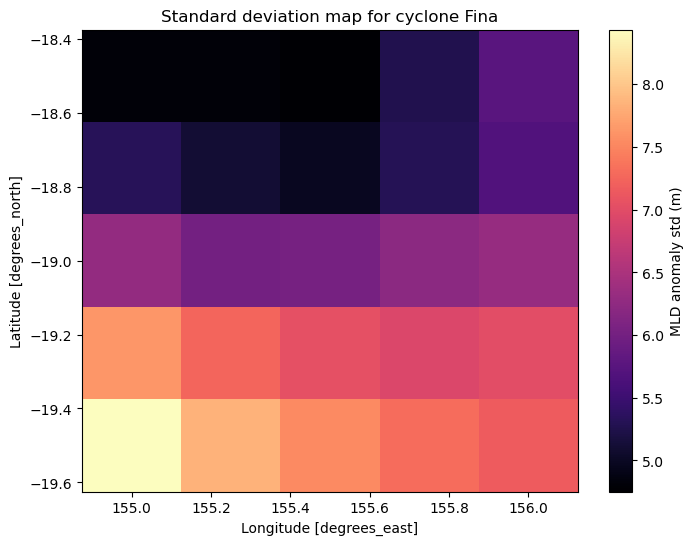

In [25]:
# Standard deviation map for Fina
fig, ax = plt.subplots(figsize=(8,6))

mld_fina_anomaly.std(dim="time", skipna=True).plot(
    ax=ax,
    cmap="magma",
    cbar_kwargs={"label": "MLD anomaly std (m)"}
)

ax.set_title("Standard deviation map for cyclone Fina")